In [ ]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

Poisson equation $\nabla^2 p = b$

In [ ]:
T = 10
n_short = 10
n_gap = 20

DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-solver" / "T10_data"

# 960x512
p_file = DATA_DIR / "cell_center_data" / "p" / f"dxdy_960x512_p_T{T}_S{n_short}_G{n_gap}.npy"
b_file = DATA_DIR / "cell_center_data" / "b" / f"dxdy_960x512_b_T{T}_S{n_short}_G{n_gap}.npy"

# likely still 962x514
eta_file = DATA_DIR / "eta" / f"dxdy_960x512_eta_T{T}_S{n_short}_G{n_gap}.npy"


In [12]:
p_grid = np.load(p_file)
b_grid = np.load(b_file)
eta_grid = np.load(eta_file)

print(f"The shape of the raw p array is: {p_grid.shape}")
print(f"The shape of the raw b array is: {b_grid.shape}")
print(f"The shape of the raw eta array is: {eta_grid.shape}")

eta_grid = eta_grid[1:-1, 1:-1]
print(f"The shape of the raw eta array is: {eta_grid.shape}")

The shape of the raw p array is: (960, 512)
The shape of the raw b array is: (960, 512)
The shape of the raw eta array is: (962, 514)
The shape of the raw eta array is: (960, 512)


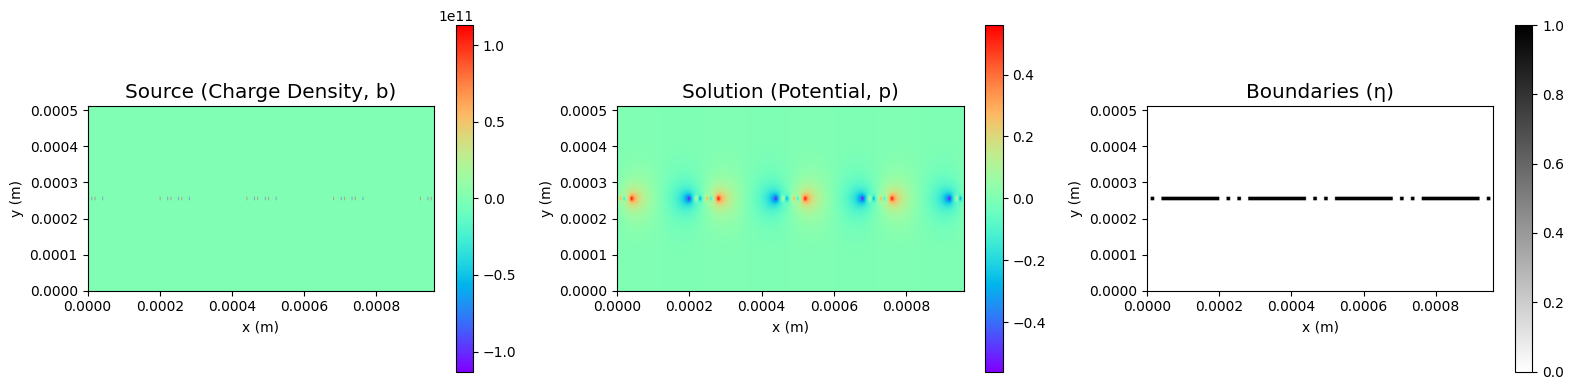

In [19]:
# 1. Define the physical extents (from L = 1.0e-6)
L = 1.0e-6
l_x = L * 960
l_y = L * 512
ext = [0, l_x, 0, l_y]

fig = plt.figure(figsize=(16, 4)) # Made it a bit wider to fit 3 plots

# Source (Charge Density, b)
ax1 = fig.add_subplot(1, 3, 1)
s_plot = b_grid.T
mesh1 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Source (Charge Density, b)', fontsize='x-large')

# Solution (Electric Potential, p)
ax2 = fig.add_subplot(1, 3, 2)
s_plot = p_grid.T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Solution (Potential, p)', fontsize='x-large')

# Boundaries (Magnets / Sifter, eta)
ax3 = fig.add_subplot(1, 3, 3)
s_plot = eta_grid.T
mesh3 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='binary', extent=ext, aspect=1.)
plt.colorbar(mesh3)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Boundaries (\u03B7)', fontsize='x-large')

plt.tight_layout()
plt.show()